Exploratory Data Analysis on SOC CrossWalk SpreadSheet

In [24]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.width", 250)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 70)

DATA = Path(__file__).resolve().parent.parent / "data" if "__file__" in globals() else Path("../data")
OUT = DATA.parent / "notebooks" / "figures"
OUT.mkdir(exist_ok=True)

Load + integrity checks

In [25]:
cw = pd.read_excel(DATA / "soc_2010_to_2018_crosswalk.xlsx", header=8, dtype=str)
cw.columns = ["soc10", "title10", "soc18", "title18"]
cw = cw.apply(lambda s: s.str.strip())

print("rows:", len(cw))
print("nulls:", cw.isna().sum().to_dict())
print("duplicate rows:", cw.duplicated().sum())
for c in ["soc10", "soc18"]:
    assert cw[c].str.fullmatch(r"\d{2}-\d{4}").all(), f"bad code format in {c}"

n_soc10, n_soc18 = cw.soc10.nunique(), cw.soc18.nunique()
print("unique 2010 codes:", n_soc10, "| unique 2018 codes:", n_soc18)
# The published SOC structures have exactly 840 (2010) and 867 (2018) detailed occupations,
# so the crosswalk is complete on both sides: no orphan codes.
assert (n_soc10, n_soc18) == (840, 867)

rows: 900
nulls: {'soc10': 0, 'title10': 0, 'soc18': 0, 'title18': 0}
duplicate rows: 0
unique 2010 codes: 840 | unique 2018 codes: 867


##### 2. Classify each code (per code, not per row)
A row-level label double-counts: one 2010 code can feed both a clean split and a merge.
So classify each code on its own side:
 - 2010 code: `1:1`, `split` (fans out, no destination shared), `into merge` (single destination shared with others), `split + merge` (fans out and some destination is shared)
 - 2018 code: mirror image.

In [26]:
cw["fanout"] = cw.groupby("soc10").soc18.transform("nunique")  # 2018 codes per 2010 code
cw["fanin"] = cw.groupby("soc18").soc10.transform("nunique")   # 2010 codes per 2018 code


def classify(df, key, own, other):
    g = df.groupby(key).agg(own=(own, "max"), other_max=(other, "max"))
    many_own, many_other = g.own > 1, g.other_max > 1
    return pd.Series(
        pd.Categorical(
            [
                "1:1" if not a and not b else "split" if a and not b else
                "into merge" if b and not a else "split + merge"
                for a, b in zip(many_own, many_other)
            ],
            categories=["1:1", "split", "into merge", "split + merge"],
        ),
        index=g.index,
    )


type10 = classify(cw, "soc10", "fanout", "fanin")
type18 = classify(cw.rename(columns={"fanin": "a", "fanout": "b"}), "soc18", "a", "b")
type18 = type18.cat.rename_categories({"split": "merge", "into merge": "from split",
                                       "split + merge": "merge + split"})

summary10 = type10.value_counts().sort_index()
summary18 = type18.value_counts().sort_index()
assert summary10.sum() == n_soc10 and summary18.sum() == n_soc18
print("2010 codes by type:\n", summary10.to_string(), "\n")
print("2018 codes by type:\n", summary18.to_string())

2010 codes by type:
 1:1              766
split             18
into merge        32
split + merge     24 

2018 codes by type:
 1:1              766
merge             11
from split        70
merge + split     20


**1:1 is not the same as unchanged.** Break the 1:1 codes down further: same code and
title, same code but renamed, or a new code (pure recode).

In [27]:
cw["title18_clean"] = cw.title18.str.replace(r"\s*\(#+\)\s*$", "", regex=True)
cw["title10_clean"] = cw.title10.str.replace(r"\s*\(#+\)\s*$", "", regex=True)
one = cw[cw.soc10.map(type10) == "1:1"].copy()
one["kind"] = "unchanged"
one.loc[(one.soc10 == one.soc18) & (one.title10_clean != one.title18_clean), "kind"] = "renamed, same code"
one.loc[one.soc10 != one.soc18, "kind"] = "recoded"
print(one.kind.value_counts().to_string())

kind
unchanged             681
renamed, same code     48
recoded                37


In [28]:
# Pure recodes: joining on raw code silently drops these (e.g. the whole physician block,
# nursing/home-health aides, most computer occupations).
one.loc[one.kind == "recoded", ["soc10", "title10", "soc18", "title18"]]

,soc10,title10,soc18,title18
26,11-9061,Funeral Service Managers,11-9171,Funeral Home Managers
75,15-1111,Computer and Information Research Scientists,15-1221,Computer and Information Research Scientists
76,15-1121,Computer Systems Analysts,15-1211,Computer Systems Analysts
77,15-1122,Information Security Analysts,15-1212,Information Security Analysts
78,15-1131,Computer Programmers,15-1251,Computer Programmers
87,15-1142,Network and Computer Systems Administrators,15-1244,Network and Computer Systems Administrators
88,15-1143,Computer Network Architects,15-1241,Computer Network Architects
89,15-1151,Computer User Support Specialists,15-1232,Computer User Support Specialists
90,15-1152,Computer Network Support Specialists,15-1231,Computer Network Support Specialists
181,19-4091,"Environmental Science and Protection Technicians, Including Health",19-4042,"Environmental Science and Protection Technicians, Including Health"


In [29]:
one.loc[one.kind == "renamed, same code", ["soc10", "title10", "title18"]]

,soc10,title10,title18
20,11-9031,"Education Administrators, Preschool and Childcare Center/Program","Education and Childcare Administrators, Preschool and Daycare"
21,11-9032,"Education Administrators, Elementary and Secondary School","Education Administrators, Kindergarten through Secondary"
27,11-9071,Gaming Managers,Gambling Managers
109,17-2031,Biomedical Engineers,Bioengineers and Biomedical Engineers
129,17-3021,Aerospace Engineering and Operations Technicians,Aerospace Engineering and Operations Technologists and Technicians
130,17-3022,Civil Engineering Technicians,Civil Engineering Technologists and Technicians
131,17-3023,Electrical and Electronics Engineering Technicians,Electrical and Electronic Engineering Technologists and Technicians
132,17-3024,Electro-Mechanical Technicians,Electro-Mechanical and Mechatronics Technologists and Technicians
133,17-3025,Environmental Engineering Technicians,Environmental Engineering Technologists and Technicians
134,17-3026,Industrial Engineering Technicians,Industrial Engineering Technologists and Technicians


##### 3. Validate the BLS flags
In this file `(#)` is appended to **2010** titles that are split, and `(##)` to **2018**
titles formed by a merge. (DATA-DICTIONARY 2.4 describes `#` as marking the 2018 side;
the file puts it on the 2010 side.) Check they agree exactly with the computed structure.

In [30]:
cw["flag10"] = cw.title10.str.contains(r"\(#\)")
cw["flag18"] = cw.title18.str.contains(r"\(##\)")
print(pd.crosstab(cw.flag10, cw.fanout > 1, rownames=["(#) on 2010 title"], colnames=["2010 code splits"]))
print(pd.crosstab(cw.flag18, cw.fanin > 1, rownames=["(##) on 2018 title"], colnames=["2018 code is a merge"]))
assert (cw.flag10 == (cw.fanout > 1)).all() and (cw.flag18 == (cw.fanin > 1)).all()

2010 code splits   False  True 
(#) on 2010 title              
False                798      0
True                   0    102
2018 code is a merge  False  True 
(##) on 2018 title                
False                   836      0
True                      0     64


##### 4. Trends by major group
Stability = share of a major group's 2010 codes that map 1:1. Occupations *in* each 2018
major group are counted on the 2018 side (codes can change major group).

In [31]:
cw["mg10"], cw["mg18"] = cw.soc10.str[:2], cw.soc18.str[:2]
codes10 = cw.drop_duplicates("soc10").assign(type=lambda d: d.soc10.map(type10))
by_mg = pd.DataFrame({
    "codes_2010": codes10.groupby("mg10").size(),
    "codes_2018": cw.drop_duplicates("soc18").groupby("mg18").size(),
    "one_to_one_2010": codes10[codes10.type == "1:1"].groupby("mg10").size(),
}).fillna(0).astype(int)
by_mg["net_change"] = by_mg.codes_2018 - by_mg.codes_2010
by_mg["pct_1to1"] = (by_mg.one_to_one_2010 / by_mg.codes_2010).round(2)
by_mg.sort_values("pct_1to1")

,codes_2010,codes_2018,one_to_one_2010,net_change,pct_1to1
15,19,21,12,2,0.63
53,52,53,42,1,0.81
27,41,41,34,0,0.83
29,61,72,53,11,0.87
45,15,14,13,-1,0.87
13,32,35,28,3,0.88
39,33,33,29,0,0.88
35,18,17,16,-1,0.89
33,22,24,20,2,0.91
19,43,48,39,5,0.91


In [32]:
# "All Other" residual codes carry most of the churn.
res = codes10.assign(residual=codes10.title10.str.contains("All Other"))
pd.crosstab(res.residual, res.type, margins=True)

type,1:1,split,into merge,split + merge,All
residual,,,,,
False,717,9,27,13,766
True,49,9,5,11,74
All,766,18,32,24,840


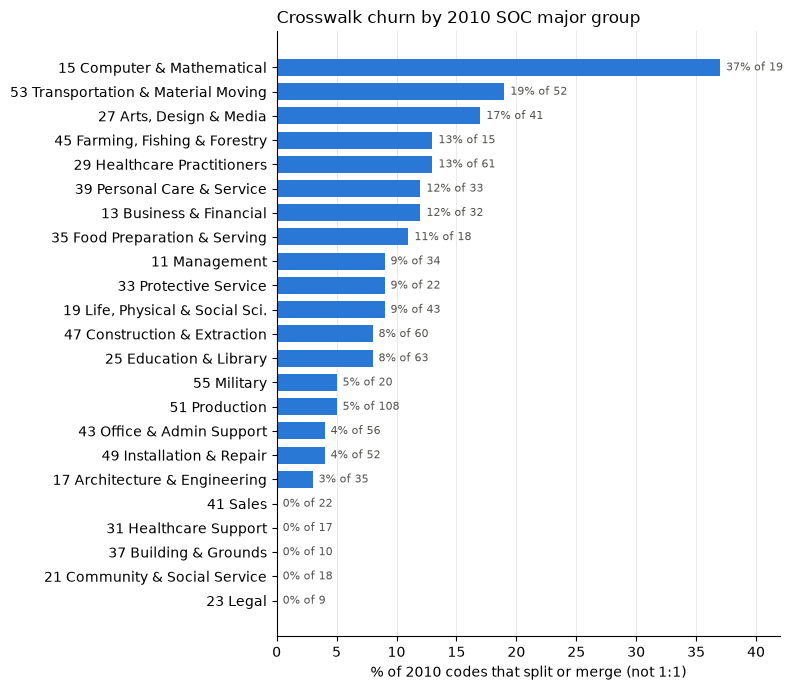

In [33]:
MAJOR_GROUPS = {
    "11": "Management", "13": "Business & Financial", "15": "Computer & Mathematical",
    "17": "Architecture & Engineering", "19": "Life, Physical & Social Sci.",
    "21": "Community & Social Service", "23": "Legal", "25": "Education & Library",
    "27": "Arts, Design & Media", "29": "Healthcare Practitioners", "31": "Healthcare Support",
    "33": "Protective Service", "35": "Food Preparation & Serving", "37": "Building & Grounds",
    "39": "Personal Care & Service", "41": "Sales", "43": "Office & Admin Support",
    "45": "Farming, Fishing & Forestry", "47": "Construction & Extraction",
    "49": "Installation & Repair", "51": "Production", "53": "Transportation & Material Moving",
    "55": "Military",
}
# Plot the complement (% changed) so the unstable groups are the long bars.
plot = by_mg.assign(pct_changed=1 - by_mg.pct_1to1).sort_values("pct_changed")
labels = [f"{mg} {MAJOR_GROUPS[mg]}" for mg in plot.index]
fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(labels, plot.pct_changed * 100, color="#2a78d6", height=0.7)
for y, (v, n) in enumerate(zip(plot.pct_changed, plot.codes_2010)):
    ax.text(v * 100 + 0.5, y, f"{v:.0%} of {n}", va="center", fontsize=8, color="#52514e")
ax.set_xlim(0, 42)
ax.set_xlabel("% of 2010 codes that split or merge (not 1:1)")
ax.set_title("Crosswalk churn by 2010 SOC major group", loc="left")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", color="#e5e5e3", linewidth=0.6)
ax.set_axisbelow(True)
fig.tight_layout()
fig.savefig(OUT / "crosswalk_churn_by_major_group.png", dpi=150)

5. Structural outliers

In [34]:
# Largest fan-out (one 2010 occupation -> many 2018 occupations)
fan_out = cw.groupby(["soc10", "title10"]).soc18.nunique().sort_values(ascending=False)
fan_out[fan_out > 2]

soc10    title10                                                                                       
29-1069  Physicians and Surgeons, All Other (#)                                                            8
15-1199  Computer Occupations, All Other (#)                                                               5
11-9199  Managers, All Other (#)                                                                           4
25-3099  Teachers and Instructors, All Other (#)                                                           3
29-1067  Surgeons (#)                                                                                      3
25-9041  Teacher Assistants (#)                                                                            3
29-9099  Healthcare Practitioners and Technical Workers, All Other (#)                                     3
39-1021  First-Line Supervisors of Personal Service Workers (#)                                            3
51-9199  Production Work

In [35]:
cw.loc[cw.soc10 == fan_out.index[0][0], ["soc18", "title18"]]

,soc18,title18
342,29-1212,Cardiologists
343,29-1213,Dermatologists
344,29-1214,Emergency Medicine Physicians
345,29-1217,Neurologists
346,29-1222,"Physicians, Pathologists"
347,29-1224,Radiologists
348,29-1229,"Physicians, All Other"
349,29-1241,"Ophthalmologists, Except Pediatric"


In [36]:
# Largest fan-in (many 2010 occupations -> one 2018 occupation)
fan_in = cw.groupby(["soc18", "title18"]).soc10.nunique().sort_values(ascending=False)
fan_in[fan_in > 1].head(10)

soc18    title18                                                                   
13-1082  Project Management Specialists (##)                                           3
15-1253  Software Quality Assurance Analysts and Testers (##)                          3
15-1299  Computer Occupations, All Other (##)                                          2
29-9021  Health Information Technologists and Medical Registrars (##)                  2
27-3023  News Analysts, Reporters, and Journalists (##)                                2
27-3099  Media and Communication Workers, All Other (##)                               2
19-4044  Hydrologic Technicians (##)                                                   2
17-3029  Engineering Technologists and Technicians, Except Drafters, All Other (##)    2
13-2054  Financial Risk Specialists (##)                                               2
15-1243  Database Architects (##)                                                      2
Name: soc10, dtype: int64

In [37]:
# Many-to-many tangles: rows where the 2010 code splits AND the 2018 code is a merge.
cw.loc[(cw.fanout > 1) & (cw.fanin > 1), ["soc10", "title10", "soc18", "title18"]]

,soc10,title10,soc18,title18
38,11-9199,"Managers, All Other (#)",13-1082,Project Management Specialists (##)
57,13-1199,"Business Operations Specialists, All Other (#)",13-1082,Project Management Specialists (##)
65,13-2051,Financial Analysts (#),13-2054,Financial Risk Specialists (##)
73,13-2099,"Financial Specialists, All Other (#)",13-2054,Financial Risk Specialists (##)
79,15-1132,"Software Developers, Applications (#)",15-1252,Software Developers (##)
80,15-1132,"Software Developers, Applications (#)",15-1253,Software Quality Assurance Analysts and Testers (##)
81,15-1133,"Software Developers, Systems Software (#)",15-1252,Software Developers (##)
82,15-1133,"Software Developers, Systems Software (#)",15-1253,Software Quality Assurance Analysts and Testers (##)
84,15-1134,Web Developers (#),15-1255,Web and Digital Interface Designers (##)
86,15-1141,Database Administrators (#),15-1243,Database Architects (##)


In [38]:
# Codes that move to a different major group
cw.loc[cw.mg10 != cw.mg18, ["soc10", "title10", "soc18", "title18"]]

,soc10,title10,soc18,title18
38,11-9199,"Managers, All Other (#)",13-1082,Project Management Specialists (##)
91,15-1199,"Computer Occupations, All Other (#)",13-1082,Project Management Specialists (##)
210,23-2091,Court Reporters,27-3092,Court Reporters and Simultaneous Captioners
317,27-4013,Radio Operators,43-2099,"Communications Equipment Operators, All Other (##)"
393,29-9011,Occupational Health and Safety Specialists,19-5011,Occupational Health and Safety Specialists
394,29-9012,Occupational Health and Safety Technicians,19-5012,Occupational Health and Safety Technicians
473,39-1021,First-Line Supervisors of Personal Service Workers (#),53-1044,First-line Supervisors of Passenger Attendants (##)
499,39-9021,Personal Care Aides,31-1122,Personal Care Aides
566,43-5081,Stock Clerks and Order Fillers,53-7065,Stockers and Order Fillers
572,43-9011,Computer Operators,15-1299,"Computer Occupations, All Other (##)"


##### 6. What this means for the index merge
Frey-Osborne is keyed to 2010 SOC; Eloundou (O*NET-SOC 2019) rolls up to 2018 SOC.

In [39]:
fo = pd.read_csv(DATA / "frey_osborne_probabilities.csv", dtype={"soc_code_2010": str})
elo = pd.read_csv(DATA / "occ_level.csv")
elo6 = elo["O*NET-SOC Code"].str[:7].unique()

fo_codes = set(fo.soc_code_2010)
print("FO codes:", len(fo_codes), "| not in crosswalk 2010 side:", len(fo_codes - set(cw.soc10)))
print("FO codes by mapping type:\n", type10[type10.index.isin(fo_codes)].value_counts().sort_index().to_string())

# 2018 codes reachable from at least one FO-scored 2010 code
fo18 = set(cw.loc[cw.soc10.isin(fo_codes), "soc18"])
print("\n2018 codes with an FO ancestor:", len(fo18), "of", n_soc18)

elo_set = set(elo6)
print("Eloundou six-digit codes:", len(elo_set), "| not in crosswalk 2018 side:",
      len(elo_set - set(cw.soc18)))
both = fo18 & elo_set
print("2018 codes with both FO and Eloundou:", len(both))

FO codes: 653 | not in crosswalk 2010 side: 0
FO codes by mapping type:
 1:1              608
split              8
into merge        21
split + merge     16

2018 codes with an FO ancestor: 668 of 867
Eloundou six-digit codes: 798 | not in crosswalk 2018 side: 0
2018 codes with both FO and Eloundou: 663


In [40]:
# 2018 codes scored by Eloundou whose FO value would have to come through a split or merge
# (provenance flag candidates), and 2018 codes with a partial FO ancestry in merges.
cw_fo = cw.assign(has_fo=cw.soc10.isin(fo_codes))
partial = cw_fo.groupby("soc18").has_fo.agg(["sum", "size"])
partial = partial[(partial["sum"] > 0) & (partial["sum"] < partial["size"])]
print("2018 merges where only some 2010 ancestors have an FO score:", len(partial))
inherited = cw_fo[cw_fo.has_fo & cw_fo.soc18.isin(elo_set) & ((cw_fo.fanout > 1) | (cw_fo.fanin > 1))]
print("Eloundou-scored 2018 codes whose FO value comes through a split/merge:", inherited.soc18.nunique())
print(partial.rename(columns={"sum": "ancestors_with_fo", "size": "ancestors"})
      .join(cw.drop_duplicates("soc18").set_index("soc18").title18))

2018 merges where only some 2010 ancestors have an FO score: 15
Eloundou-scored 2018 codes whose FO value comes through a split/merge: 55
         ancestors_with_fo  ancestors                                                                title18
soc18                                                                                                       
13-1082                  2          3                                    Project Management Specialists (##)
15-1243                  1          2                                               Database Architects (##)
15-1253                  2          3                   Software Quality Assurance Analysts and Testers (##)
15-1299                  1          2                                   Computer Occupations, All Other (##)
17-3029                  1          2  Engineering Technologists and Technicians, Except Drafters, All Ot...
27-3099                  1          2                        Media and Communication Workers, All O

In [41]:
# Value-conflict outliers: merges whose 2010 ancestors disagree on FO probability.
# Whatever aggregation rule the team picks (mean, employment-weighted, max) decides these scores.
m = cw.merge(fo, left_on="soc10", right_on="soc_code_2010", how="left")
spread = (m.groupby(["soc18", "title18"]).fo_computerization_probability.agg(["count", "min", "max"])
          .query("count > 1").assign(spread=lambda d: d["max"] - d["min"])
          .sort_values("spread", ascending=False))
spread.head(15)

,,count,min,max,spread
soc18,title18,,,,
47-5032,"Explosives Workers, Ordnance Handling Experts, and Blasters (##)",2,0.480,0.85,0.370
19-4044,Hydrologic Technicians (##),2,0.610,0.91,0.300
25-4022,Librarians and Media Collections Specialists (##),2,0.390,0.65,0.260
51-9124,"Coating, Painting, and Spraying Machine Setters, Operators, and Tenders (##)",2,0.690,0.91,0.220
47-5044,"Loading and Moving Machine Operators, Underground Mining (##)",2,0.370,0.50,0.130
53-4022,"Railroad Brake, Signal, and Switch Operators and Locomotive Firers (##)",2,0.830,0.93,0.100
13-2054,Financial Risk Specialists (##),2,0.230,0.33,0.100
15-1252,Software Developers (##),2,0.042,0.13,0.088
15-1253,Software Quality Assurance Analysts and Testers (##),2,0.042,0.13,0.088


In [42]:
# Worked example: Software Developers. Two 2010 codes feed two 2018 codes, each 2018 code
# receives from both, so any FO/AIOE value assigned here is an average by construction.
sw = cw[cw.soc10.isin(["15-1132", "15-1133"])][["soc10", "title10", "soc18", "title18"]]
sw.merge(fo, left_on="soc10", right_on="soc_code_2010", how="left").drop(columns="soc_code_2010")

,soc10,title10,soc18,title18,fo_computerization_probability
0,15-1132,"Software Developers, Applications (#)",15-1252,Software Developers (##),0.042
1,15-1132,"Software Developers, Applications (#)",15-1253,Software Quality Assurance Analysts and Testers (##),0.042
2,15-1133,"Software Developers, Systems Software (#)",15-1252,Software Developers (##),0.130
3,15-1133,"Software Developers, Systems Software (#)",15-1253,Software Quality Assurance Analysts and Testers (##),0.130


##### 7. Summary: key trends, merging, and outliers

**General trends**
- The crosswalk is complete: 900 rows link all 840 SOC 2010 codes to all 867 SOC 2018 codes, with no nulls, duplicates, or badly formatted codes.
- 766 codes map 1:1, but only 681 of those are truly unchanged: 48 kept their code but were renamed, and 37 kept the occupation under a **new code** (most computer occupations, the physician block, nursing/home health aides).
- The BLS flags are reliable: `(#)` on a 2010 title marks a split and `(##)` on a 2018 title marks a merge, matching the computed structure exactly (102 and 64 rows).
- Churn is concentrated: Computer & Mathematical (group 15) has 37% of its codes split or merged, Transportation (53) 19%, Arts & Media (27) 17%. Legal, Sales, Healthcare Support, Building & Grounds, and Community & Social Service have none.
- "All Other" catch-all codes drive the churn: 66% of them map 1:1, against 94% of all other codes.

**Merging**
- Always join 2010-keyed indices (Frey-Osborne, AIOE) to 2018 codes through the crosswalk, never on raw code or title; a raw-code join silently drops the 37 recoded occupations.
- 663 of the 2018 codes end up with both a Frey-Osborne score and an Eloundou score, within the expected 650-750 range.
- For 55 of those codes, the Frey-Osborne value comes through a split or merge; flag them in a provenance column.
- A rule is needed for merges (mean, max, or employment-weighted); document the choice.

**Outliers (structural, not statistical)**
- Largest split: `29-1069` Physicians and Surgeons, All Other becomes 8 codes.
- Largest merges: `13-1082` Project Management Specialists and `15-1253` Software QA Analysts and Testers each draw on 3 codes.
- 14 rows change major group (e.g. Court Reporters 23 -> 27, Radar and Sonar Technicians 55 -> 17).
- 12 merges have source jobs that disagree on Frey-Osborne score, most sharply Hydrologic Technicians (0.61-0.91), Explosives Workers (0.48-0.85), and Librarians (0.39-0.65). Their merged score depends on the rule chosen.

##### EDA techniques applied

| Technique | What it was used for | Section |
|---|---|---|
| Header detection / skipping preamble rows | The sheet has 8 rows of BLS notes above the real header (`header=8`) | 1 |
| Reading codes as strings (`dtype=str`) | Keeps leading zeros and the `##-####` format intact | 1 |
| Missing-value and duplicate-row checks | `isna().sum()`, `duplicated().sum()` | 1 |
| Format validation with regex + `assert` | Every code matches `\d{2}-\d{4}` | 1 |
| Cardinality checks against a published reference | 840 / 867 unique codes match the official SOC 2010 / 2018 counts, so no codes are missing | 1 |
| Relationship (cardinality) analysis | Fan-out and fan-in per code with `groupby().nunique()`, classifying each code as 1:1, split, merge, or both | 2 |
| Reconciliation asserts | Category counts must sum to exactly 840 and 867 | 2 |
| Text cleaning + string comparison | Stripping `(#)`/`(##)` markers to separate unchanged, renamed, and recoded occupations | 2 |
| Cross-tabulation to validate source flags | `pd.crosstab` of the BLS markers vs the computed splits/merges | 3 |
| Group-by aggregation on a derived feature | Major group = first two digits of the code; churn rate per group | 4 |
| Segment comparison | "All Other" catch-all codes vs specific codes | 4 |
| Visualization | Horizontal bar chart of churn by major group, sorted so outliers stand out | 4 |
| Structural outlier detection | Top fan-out, top fan-in, many-to-many tangles, cross-major-group moves (not z-scores: the crosswalk is a mapping, not a sample) | 5 |
| Coverage / join analysis | Joining the crosswalk to Frey-Osborne and Eloundou to count matched, unmatched, and crosswalk-dependent codes | 6 |
| Value-conflict detection | Min/max spread of Frey-Osborne scores within each merged 2018 code | 6 |